In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()   # upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ajmainislam","key":"8918fce514f40cf50b818500575f40dd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset


Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
 92% 728M/787M [00:10<00:01, 42.1MB/s]
100% 787M/787M [00:10<00:00, 77.7MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("kaggle-cat-vs-dog-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("cat_dog_dataset")

print("Extracted to: /content/cat_dog_dataset")


Extracted to: /content/cat_dog_dataset


In [ ]:
import os

base_path = "/content/cat_dog_dataset"

for root, dirs, files in os.walk(base_path):
    print("Folder:", root)
    print("Number of images:", len(files))
    print("-" * 40)


Folder: /content/cat_dog_dataset
Number of images: 0
----------------------------------------
Folder: /content/cat_dog_dataset/kagglecatsanddogs_3367a
Number of images: 2
----------------------------------------
Folder: /content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages
Number of images: 0
----------------------------------------
Folder: /content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages/Cat
Number of images: 12491
----------------------------------------
Folder: /content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages/Dog
Number of images: 12470
----------------------------------------


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

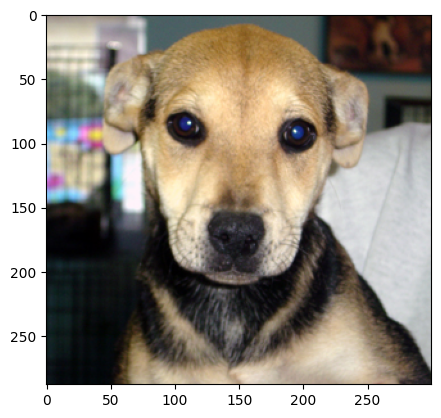

In [ ]:
img = mpimg.imread('/content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages/Dog/4.jpg')
imgplt = plt.imshow(img)
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

data_dir = "/content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages"

IMG_SIZE = 128
LIMIT_PER_CLASS = 1000

data = []
labels = []

categories = ["Cat", "Dog"]

for category in categories:
    folder_path = os.path.join(data_dir, category)
    label = categories.index(category)

    count = 0

    for img_name in os.listdir(folder_path):
        if count >= LIMIT_PER_CLASS:
            break

        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img)
            labels.append(label)
            count += 1

        except:
            continue

# Convert to NumPy arrays
X = np.array(data, dtype="float32")
y = np.array(labels)

# Normalize
X = X / 255.0

print("Images shape:", X.shape)
print("Labels shape:", y.shape)


Images shape: (2000, 128, 128, 3)
Labels shape: (2000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1600, 128, 128, 3)
Test shape: (400, 128, 128, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


In [ ]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # Binary classification
])


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 477ms/step - accuracy: 0.8709 - loss: 0.2789 - val_accuracy: 0.9525 - val_loss: 0.1378
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - accuracy: 0.9631 - loss: 0.0928 - val_accuracy: 0.9525 - val_loss: 0.1338
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 441ms/step - accuracy: 0.9811 - loss: 0.0546 - val_accuracy: 0.9375 - val_loss: 0.1608
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 459ms/step - accuracy: 0.9861 - loss: 0.0437 - val_accuracy: 0.9550 - val_loss: 0.1340
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 436ms/step - accuracy: 0.9929 - loss: 0.0240 - val_accuracy: 0.9525 - val_loss: 0.1466


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


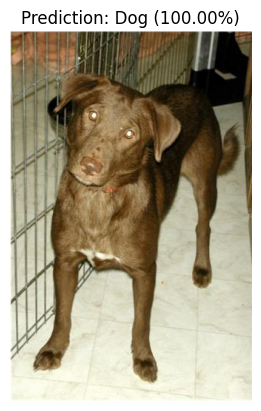

('Dog', np.float32(0.9999922))

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 128

def predict_image(image_path, model):

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    img_array = img_resized / 255.0

    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)
    probability = prediction[0][0]

    if probability > 0.5:
        label = "Dog"
        confidence = probability
    else:
        label = "Cat"
        confidence = 1 - probability


    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

    return label, confidence
image_path = "/content/cat_dog_dataset/kagglecatsanddogs_3367a/PetImages/Dog/1.jpg"

predict_image(image_path, model)
